## Exercise: Compute derivatives via backpropragation

DL concepts for PDEs such as PINNs or DeepRitz require the computation of derivatives of the outputs of a neural network with respect to its input. To do this, they rely on the 'backpropagation' algorithm for neural networks: It constructs subsequent operations as a graph and computes the derivative analytically via chain rule.

The shown method will later be used in TorchPhysics internally.

In [ ]:
import torch
import matplotlib.pyplot as plt

The code below evaluates a function and its derivative on a series of points.
To-Do: Play around with the function and change its content to have a look at the derivative of functions you know. Do the results match you expectations?

In [37]:
# create points
x = torch.linspace(0, 1, 100, requires_grad=True)[:, None]

def fun(z):
    return torch.cos(3.14 * z)

# apply function
y = fun(x)

# compute derivative via autograd
dy_dx = torch.autograd.grad(y.sum(), x)[0]

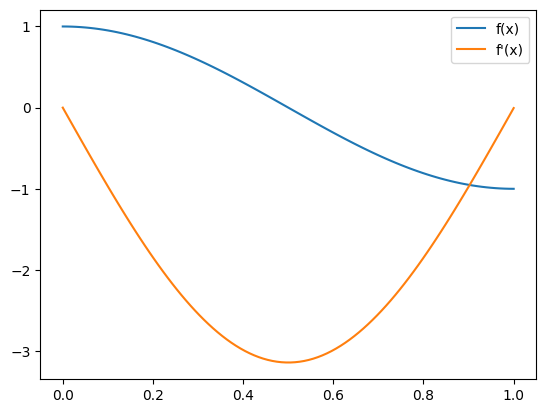

In [38]:
# visualization

plt.plot(x.detach(), y.detach(), label='f(x)')
plt.plot(x.detach(), dy_dx.detach(), label="f'(x)")
plt.legend()

Now do the same for the ouput of a Neural Network (with random initialization). You can just call `network` as a python function, i.e. `y = network(x)`.

In [ ]:
network = torch.nn.Sequential(torch.nn.Linear(1, 10),
                              torch.nn.ReLU(),
                              torch.nn.Linear(10, 1))